## Ticket Routing Recommendation problem

En este trabajo se propone el uso de un perceptrón multicapa (MLP) para abordar un problema clásico de clasificación de tickets.

La red neuronal se entrenará con los tickets. El objetivo es que el modelo aprenda a reconocer que empleado puede realizar el ticket o tarea en cuestion.

### Objetivos:
- Implementar una red neuronal MLP sencilla con Keras.
- Entrenar la red y observar la evolución de la pérdida y la precisión.
- Evaluar el modelo sobre el conjunto de test.
- Visualizar algunos ejemplos de predicciones.

Este ejercicio permite una primera toma de contacto con la clasificación automática y el entrenamiento de redes neuronales utilizando imágenes reales y una base de datos muy utilizada en benchmarking.

In [ ]:
# 1. IMPORTAR LIBRERÍAS


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
# Cargar datos
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_excel(
    "/content/drive/MyDrive/Muestra de tickets.xlsx",
    sheet_name="Muestra dragonet"
)

print(df.shape)
df.head()


Mounted at /content/drive
(9348, 24)


,Issue Type,Issue key,Issue id,Ticket ID,Assignee,Team,Employee code,Priority,Priority level,Status,...,Worked hours,Eficiencia,Request Type,Inward Tickets,Outward Tickets,Inward Project,Outward Project,Inward,Outward,Total Link
0,[System] Service request,DIG-72,10189.0,T1,Jonas De Jonge,SEC,E18,P3,2.0,Canceled,...,30.984722,0.005291,Get something new from IT,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,[System] Incident,DIG-218,10428.0,T2,Louis Pintjens,CS,E24,P4,1.0,Close without notification,...,221.166111,0.029162,Get help from the Customer Success Team (Incid...,0.0,1.0,0.0,0.0,0.0,1.0,1.0
2,[System] Incident,DIG-228,10448.0,T3,Louis Pintjens,CS,E24,P4,1.0,Close without notification,...,221.132778,0.177190,Get help from the Customer Success Team (Incid...,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,[System] Incident,DIG-236,10464.0,T4,Louis Pintjens,CS,E24,P3,2.0,Close without notification,...,221.288889,0.029178,Get help from the Customer Success Team (Incid...,0.0,1.0,0.0,0.0,0.0,1.0,1.0
4,[System] Service request,DIG-454,10869.0,T5,Gert Ivens,IT,E14,P4,1.0,Close without notification,...,47.444722,0.024406,Onboard New MPL Employees,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# 3. EXPLORAR DATOS


print(df.shape)
print(df.columns)
df.info()

(9348, 24)
Index(['Issue Type', 'Issue key', 'Issue id', 'Ticket ID', 'Assignee', 'Team',
       'Employee code', 'Priority', 'Priority level', 'Status', 'Resolution',
       'Created', 'Updated', 'Created-Update en Horas', 'Worked hours',
       'Eficiencia', 'Request Type', 'Inward Tickets', 'Outward Tickets',
       'Inward Project', 'Outward Project', 'Inward', 'Outward', 'Total Link'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9348 entries, 0 to 9347
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Issue Type               9346 non-null   object        
 1   Issue key                9346 non-null   object        
 2   Issue id                 9346 non-null   float64       
 3   Ticket ID                9346 non-null   object        
 4   Assignee                 9344 non-null   object        
 5   Team                     9344 non-null   obje

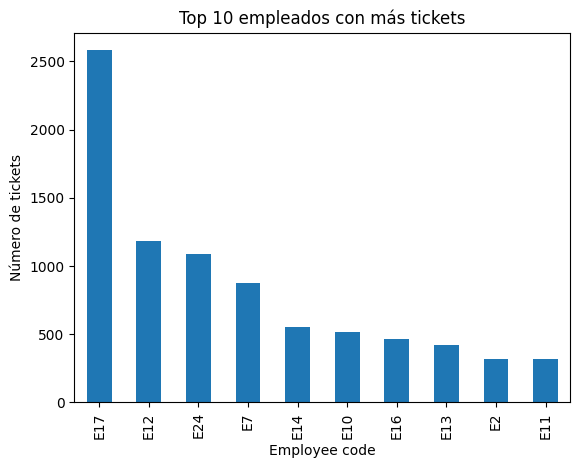

In [ ]:
# Visualizar distribución de empleados

df["Employee code"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 empleados con más tickets")
plt.xlabel("Employee code")
plt.ylabel("Número de tickets")
plt.show()

In [ ]:
# 4. SELECCIONAR VARIABLES


categoricas = [
    "Issue Type",
    "Team"
]

numericas = [
    "Priority level",
    "Total Link",
    "Inward",
    "Outward",
    "Worked hours",
    "Inward Tickets",
    "Outward Tickets",
    "Inward Project",
    "Outward Project",

]

target = "Employee code"

In [ ]:
# 5. LIMPIEZA BÁSICA


df_model = df[categoricas + numericas + [target]].copy()

df_model = df_model.dropna()

print(df_model.shape)
df_model.head()

(9344, 12)


,Issue Type,Team,Priority level,Total Link,Inward,Outward,Worked hours,Inward Tickets,Outward Tickets,Inward Project,Outward Project,Employee code
0,[System] Service request,SEC,2.0,0.0,0.0,0.0,30.984722,0.0,0.0,0.0,0.0,E18
1,[System] Incident,CS,1.0,1.0,0.0,1.0,221.166111,0.0,1.0,0.0,0.0,E24
2,[System] Incident,CS,1.0,0.0,0.0,0.0,221.132778,0.0,0.0,0.0,0.0,E24
3,[System] Incident,CS,2.0,1.0,0.0,1.0,221.288889,0.0,1.0,0.0,0.0,E24
4,[System] Service request,IT,1.0,0.0,0.0,0.0,47.444722,0.0,0.0,0.0,0.0,E14


In [ ]:
# 6. CODIFICAR VARIABLES CATEGÓRICAS


X_cat = pd.get_dummies(df_model[categoricas])
X_num = df_model[numericas]

X = pd.concat([X_cat, X_num], axis=1)

X.head()


,Issue Type_FOR JIRA TESTING PURPOSES,Issue Type_Task,Issue Type_[System] Change,Issue Type_[System] Incident,Issue Type_[System] Post-incident review,Issue Type_[System] Service request,Team_BCFIN,Team_CRM,Team_CS,Team_DATA,...,Team_SEC,Priority level,Total Link,Inward,Outward,Worked hours,Inward Tickets,Outward Tickets,Inward Project,Outward Project
0,False,False,False,False,False,True,False,False,False,False,...,True,2.0,0.0,0.0,0.0,30.984722,0.0,0.0,0.0,0.0
1,False,False,False,True,False,False,False,False,True,False,...,False,1.0,1.0,0.0,1.0,221.166111,0.0,1.0,0.0,0.0
2,False,False,False,True,False,False,False,False,True,False,...,False,1.0,0.0,0.0,0.0,221.132778,0.0,0.0,0.0,0.0
3,False,False,False,True,False,False,False,False,True,False,...,False,2.0,1.0,0.0,1.0,221.288889,0.0,1.0,0.0,0.0
4,False,False,False,False,False,True,False,False,False,False,...,False,1.0,0.0,0.0,0.0,47.444722,0.0,0.0,0.0,0.0


In [ ]:
# 7. CODIFICAR VARIABLE OBJETIVO


le = LabelEncoder()

y = le.fit_transform(df_model[target])

num_classes = len(np.unique(y))

print("Número de clases:", num_classes)
print("Empleados:", le.classes_)

Número de clases: 40
Empleados: ['E1' 'E10' 'E11' 'E12' 'E13' 'E14' 'E15' 'E16' 'E17' 'E18' 'E19' 'E2'
 'E20' 'E21' 'E22' 'E23' 'E24' 'E25' 'E26' 'E27' 'E28' 'E29' 'E3' 'E30'
 'E31' 'E32' 'E33' 'E34' 'E35' 'E36' 'E37' 'E38' 'E39' 'E4' 'E40' 'E5'
 'E6' 'E7' 'E8' 'E9']


In [ ]:
# 8. DIVIDIR EN TRAIN Y TEST


# Identify and filter out classes with only one member
class_counts = df_model[target].value_counts()
single_instance_classes = class_counts[class_counts == 1].index

# Filter df_model to exclude these classes
df_filtered = df_model[~df_model[target].isin(single_instance_classes)]

# Re-encode the target variable for the filtered data
le_filtered = LabelEncoder()
y_filtered = le_filtered.fit_transform(df_filtered[target])

# Re-create X for the filtered data
X_cat_filtered = pd.get_dummies(df_filtered[categoricas])
X_num_filtered = df_filtered[numericas]
X_filtered = pd.concat([X_cat_filtered, X_num_filtered], axis=1)

# Ensure X_filtered has the same columns as the original X
# This is important if some categorical values were removed due to filtering single instance classes
missing_cols = set(X.columns) - set(X_filtered.columns)
for c in missing_cols:
    X_filtered[c] = 0
X_filtered = X_filtered[X.columns]

x_train, x_test, y_train, y_test = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.2,
    random_state=42,
    stratify=y_filtered)

# Update num_classes to reflect the new number of unique classes after filtering
num_classes = len(np.unique(y_filtered))
print("Number of classes after filtering:", num_classes)
print("Employees after filtering:", le_filtered.classes_)

Number of classes after filtering: 32
Employees after filtering: ['E1' 'E10' 'E11' 'E12' 'E13' 'E14' 'E15' 'E16' 'E17' 'E18' 'E19' 'E2'
 'E20' 'E21' 'E22' 'E24' 'E25' 'E28' 'E29' 'E30' 'E32' 'E33' 'E35' 'E36'
 'E37' 'E38' 'E39' 'E4' 'E40' 'E5' 'E6' 'E7']


In [ ]:
# 9. NORMALIZAR DATOS


scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
# 10. CREAR MODELO DE RED NEURONAL


model = Sequential([
    Dense(128, activation="relu", input_shape=(x_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(num_classes, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 11. COMPILAR MODELO


model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,280 (51.88 KB)

 Trainable params: 13,280 (51.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 12. ENTRENAR MODELO


history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4063 - loss: 2.0548 - val_accuracy: 0.4886 - val_loss: 1.4977
Epoch 2/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4697 - loss: 1.5064 - val_accuracy: 0.4960 - val_loss: 1.4218
Epoch 3/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4712 - loss: 1.4542 - val_accuracy: 0.4920 - val_loss: 1.4191
Epoch 4/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4709 - loss: 1.4455 - val_accuracy: 0.4967 - val_loss: 1.4198
Epoch 5/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4759 - loss: 1.4238 - val_accuracy: 0.4953 - val_loss: 1.4019
Epoch 6/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4801 - loss: 1.4113 - val_accuracy: 0.4926 - val_loss: 1.3973
Epoch 7/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4766 - loss: 1.4140 - val_accuracy: 0.4813 - val_loss: 1.4024
Epoch 8/50
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4771 - loss: 1.4126 - val_accuracy: 0

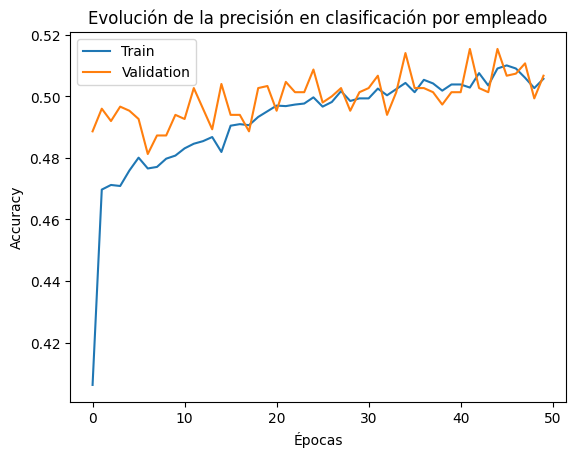

In [ ]:
# 13. GRAFICAR ACCURACY


plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Evolución de la precisión en clasificación por empleado")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

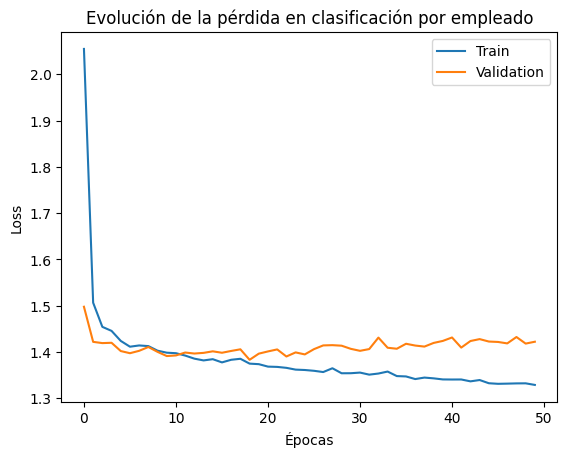

In [ ]:
# 14. GRAFICAR LOSS


plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Evolución de la pérdida en clasificación por empleado")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
# 15. EVALUAR MODELO

loss, accuracy = model.evaluate(x_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5027 - loss: 1.3557
Loss: 1.3557360172271729
Accuracy: 0.5026766657829285


In [ ]:
# 16. PREDICCIONES


y_pred_prob = model.predict(x_test)

y_pred = np.argmax(y_pred_prob, axis=1)

print(y_pred[:10])

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
[ 8  8  8  8  8  8 31 13  8  2]


In [ ]:
# Convertir predicciones numéricas a Employee code real

empleados_predichos = le.inverse_transform(y_pred)
empleados_reales = le.inverse_transform(y_test)

print("Predicciones:", empleados_predichos[:10])
print("Reales:", empleados_reales[:10])

Predicciones: ['E17' 'E17' 'E17' 'E17' 'E17' 'E17' 'E38' 'E21' 'E17' 'E11']
Reales: ['E17' 'E25' 'E12' 'E17' 'E17' 'E17' 'E38' 'E19' 'E17' 'E16']


In [ ]:
# 17. REPORTE DE CLASIFICACIÓN


# Get the unique labels present in y_test
unique_labels_in_test = np.unique(y_test)

# Map these unique numerical labels back to their original employee codes
filtered_target_names = le_filtered.inverse_transform(unique_labels_in_test)

print(classification_report(
    y_test,
    y_pred,
    labels=unique_labels_in_test,
    target_names=filtered_target_names.astype(str)
))

              precision    recall  f1-score   support

          E1       0.00      0.00      0.00         3
         E10       0.31      0.05      0.08       103
         E11       0.37      0.25      0.30        63
         E12       0.56      0.17      0.25       236
         E13       0.21      0.04      0.06        84
         E14       0.58      0.55      0.56       110
         E15       0.00      0.00      0.00         1
         E16       0.37      0.39      0.38        93
         E17       0.43      0.97      0.59       517
         E18       1.00      1.00      1.00         8
         E19       0.00      0.00      0.00         6
          E2       0.96      1.00      0.98        64
         E20       0.00      0.00      0.00         1
         E21       0.50      0.58      0.54        12
         E22       0.00      0.00      0.00         8
         E24       0.50      0.01      0.03       217
         E25       0.00      0.00      0.00         2
         E28       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


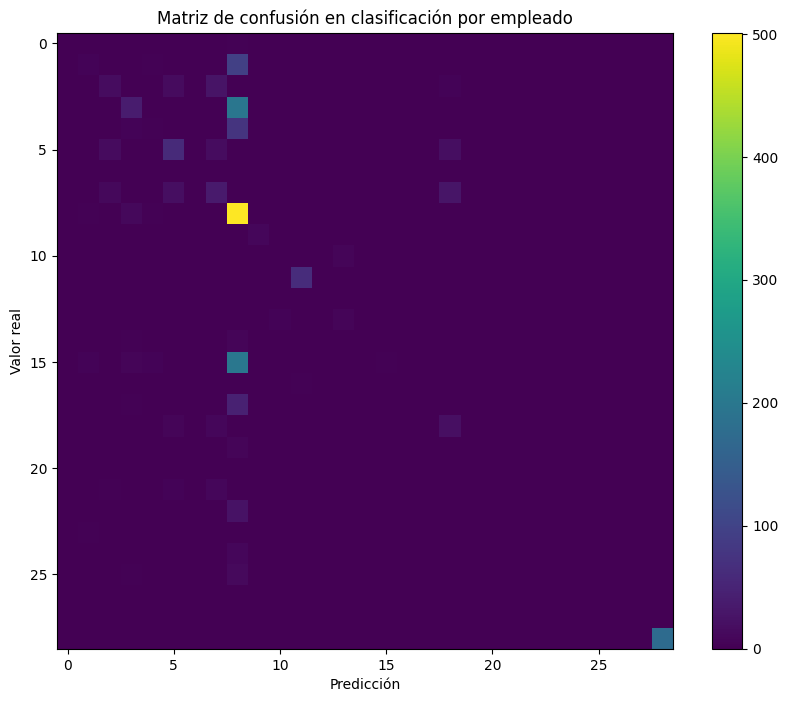

In [ ]:
# 18. MATRIZ DE CONFUSIÓN

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Matriz de confusión en clasificación por empleado")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.colorbar()
plt.show()

In [ ]:
# 19. TOP 3 EMPLEADOS RECOMENDADOS


indice_ticket = 0

probabilidades = y_pred_prob[indice_ticket]

top3_indices = np.argsort(probabilidades)[-3:][::-1]

top3_empleados = le.inverse_transform(top3_indices)
top3_probabilidades = probabilidades[top3_indices]

for empleado, prob in zip(top3_empleados, top3_probabilidades):
    print(f"Empleado recomendado: {empleado} - Probabilidad: {prob:.4f}")

Empleado recomendado: E17 - Probabilidad: 0.4190
Empleado recomendado: E12 - Probabilidad: 0.1959
Empleado recomendado: E23 - Probabilidad: 0.1636


In [ ]:
# 20. FUNCIÓN PARA PREDECIR UN NUEVO TICKET


def recomendar_empleado(nuevo_ticket):
    nuevo_df = pd.DataFrame([nuevo_ticket])

    nuevo_cat = pd.get_dummies(nuevo_df[categoricas])
    nuevo_num = nuevo_df[numericas]

    nuevo_X = pd.concat([nuevo_cat, nuevo_num], axis=1)

    nuevo_X = nuevo_X.reindex(columns=X.columns, fill_value=0)

    nuevo_X = scaler.transform(nuevo_X)

    pred_prob = model.predict(nuevo_X)

    top3 = np.argsort(pred_prob[0])[-3:][::-1]

    empleados = le.inverse_transform(top3)
    probabilidades = pred_prob[0][top3]

    return list(zip(empleados, probabilidades))

In [ ]:
# Ejemplo de nuevo ticket

nuevo_ticket = {
    "Issue Type": "Incident",
    "Team": "CRM",
    "Priority level": 2,
    "Total Link": 1,
    "Inward": 0,
    "Outward": 1,
    "Worked hours": 3.5,
    "Inward Tickets": 2,
    "Outward Tickets": 1,
    "Inward Project": 0,
    "Outward Project": 1
}

recomendar_empleado(nuevo_ticket)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


[('E36', np.float32(0.9999987)),
 ('E21', np.float32(1.2856459e-06)),
 ('E19', np.float32(5.723954e-08))]